# YouTube Video View Prediction - Exploratory Data Analysis (EDA)

This notebook performs Exploratory Data Analysis on aggregated YouTube video data and corresponding channel data.
The goal is to understand the characteristics of the data, identify patterns, and visualize relationships between features that might be useful for predicting video views.

## 1. Setup and Data Loading

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define file paths
video_data_path = "../../../Dataset/Mohamed_Dataset/snapshots/youtube_dataset_snapshot_20251028_144628.csv"
channel_data_path = "../../../Dataset/Mohamed_Dataset/snapshots/channel_list_snapshot_20251028_141613.csv"

# Load the datasets
try:
    df_videos = pd.read_csv(video_data_path)
    df_channels = pd.read_csv(channel_data_path)
    print("Datasets loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading file: {e}. Please ensure the paths are correct.")
    exit()


Datasets loaded successfully.


/var/folders/jc/f942bwtn5tjd9d_pms028ld40000gn/T/ipykernel_3870/1840710487.py:12: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df_videos = pd.read_csv(video_data_path)


## 2. Initial Data Inspection

In [2]:
print("--- Video Data Info ---")
df_videos.info()
print("-- Video Data Head ---")
print(df_videos.head())
print("--- Video Data Description ---")
print(df_videos.describe())

print("--- Channel Data Info ---")
df_channels.info()
print("--- Channel Data Head ---")
print(df_channels.head())
print("--- Channel Data Description ---")
print(df_channels.describe())

--- Video Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69331 entries, 0 to 69330
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   video_id                69331 non-null  object 
 1   channel_name            69331 non-null  object 
 2   category                69331 non-null  object 
 3   channel_id              69331 non-null  object 
 4   viewCount               69331 non-null  int64  
 5   likeCount               65783 non-null  float64
 6   commentCount            68576 non-null  float64
 7   title                   69331 non-null  object 
 8   description             0 non-null      float64
 9   tags                    0 non-null      float64
 10  publishedAt             69331 non-null  object 
 11  duration                69331 non-null  object 
 12  dimension               69242 non-null  object 
 13  definition              69242 non-null  object 
 14  caption       

## 3. Merging Datasets

In [3]:
# Both dataframes have 'channel_id', so we can merge directly.
df_merged = pd.merge(df_videos, df_channels, on='channel_id', how='left')
print("--- Merged Data Info ---")
df_merged.info()
print("--- Merged Data Head ---")
print(df_merged.head())

--- Merged Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69616 entries, 0 to 69615
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   video_id                 69616 non-null  object 
 1   channel_name_x           69616 non-null  object 
 2   category_x               69616 non-null  object 
 3   channel_id               69616 non-null  object 
 4   viewCount                69616 non-null  int64  
 5   likeCount                66065 non-null  float64
 6   commentCount             68861 non-null  float64
 7   title                    69616 non-null  object 
 8   description              0 non-null      float64
 9   tags                     0 non-null      float64
 10  publishedAt              69616 non-null  object 
 11  duration                 69616 non-null  object 
 12  dimension                69527 non-null  object 
 13  definition               69527 non-null  object 
 1

## 4. Exploratory Data Analysis (EDA) and Visualizations

### Distribution of Target Variable: View Count

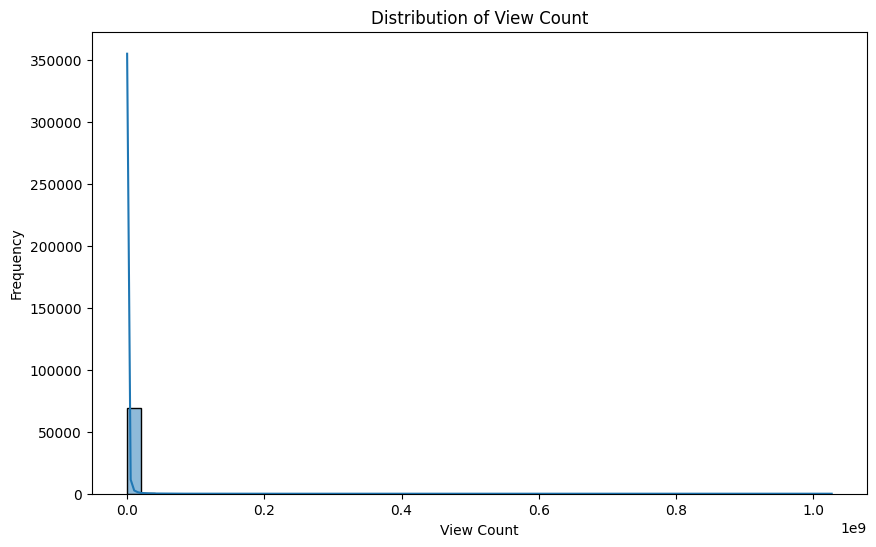

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df_merged['viewCount'], bins=50, kde=True)
plt.title('Distribution of View Count')
plt.xlabel('View Count')
plt.ylabel('Frequency')
plt.show()

### Log-transformed View Count

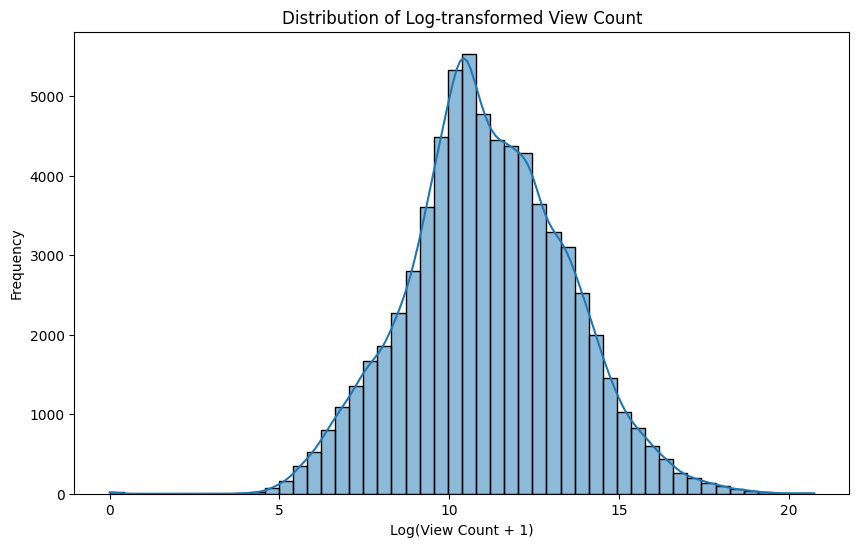

In [5]:
df_merged['log_view_count'] = df_merged['viewCount'].apply(lambda x: np.log1p(x))
plt.figure(figsize=(10, 6))
sns.histplot(df_merged['log_view_count'], bins=50, kde=True)
plt.title('Distribution of Log-transformed View Count')
plt.xlabel('Log(View Count + 1)')
plt.ylabel('Frequency')
plt.show()

### Correlation Matrix of Numerical Features

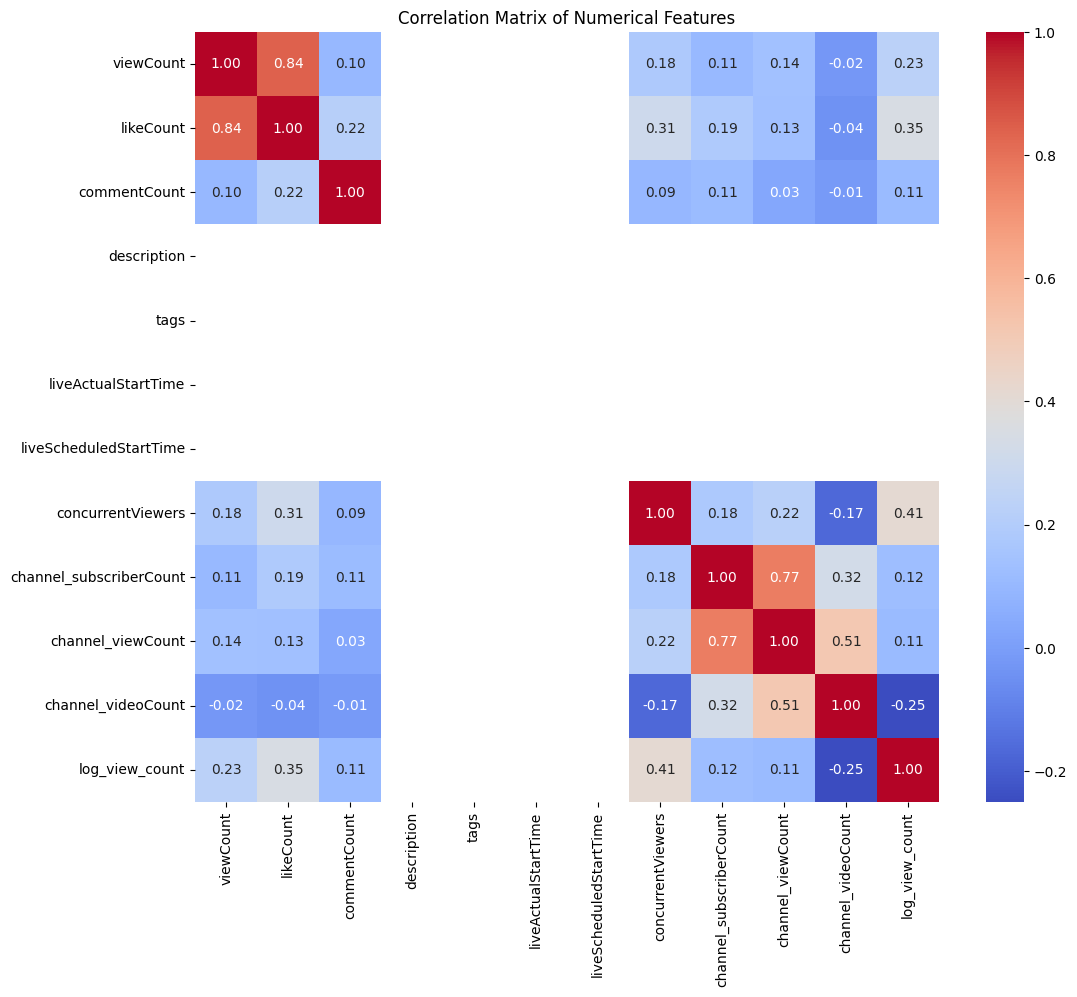

In [6]:
plt.figure(figsize=(12, 10))
numerical_cols = df_merged.select_dtypes(include=['int64', 'float64']).columns
sns.heatmap(df_merged[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Scatter Plot: View Count vs. Like Count

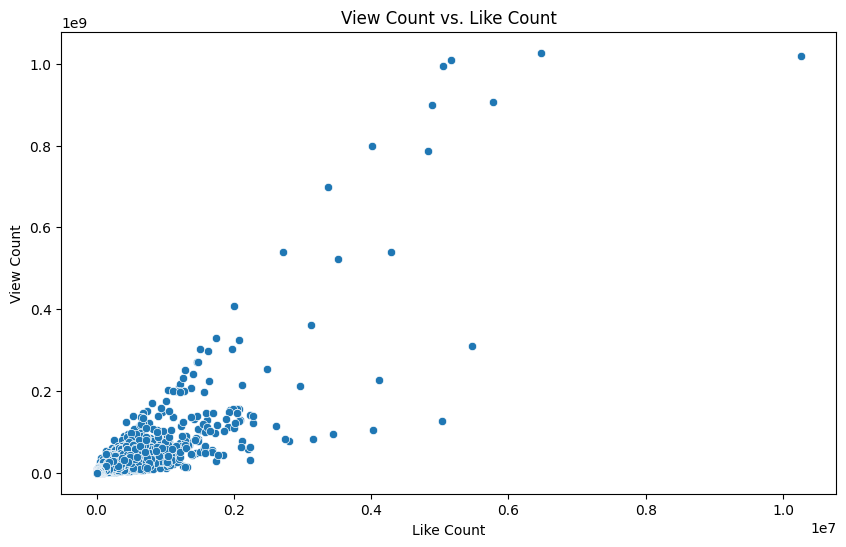

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='likeCount', y='viewCount', data=df_merged)
plt.title('View Count vs. Like Count')
plt.xlabel('Like Count')
plt.ylabel('View Count')
plt.show()

### Scatter Plot: View Count vs. Subscriber Count

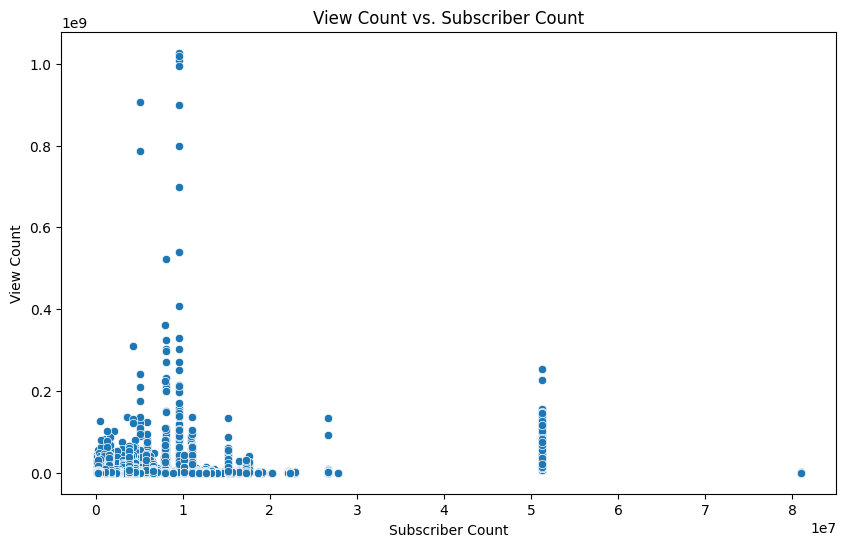

In [9]:
if 'channel_subscriberCount' in df_merged.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='channel_subscriberCount', y='viewCount', data=df_merged)
    plt.title('View Count vs. Subscriber Count')
    
    plt.xlabel('Subscriber Count')
    plt.ylabel('View Count')
    plt.show()
else:
    print("'channel_subscriberCount' column not found in merged data for visualization.")

### Time-based Analysis: View Count by Day of Week and Hour of Day

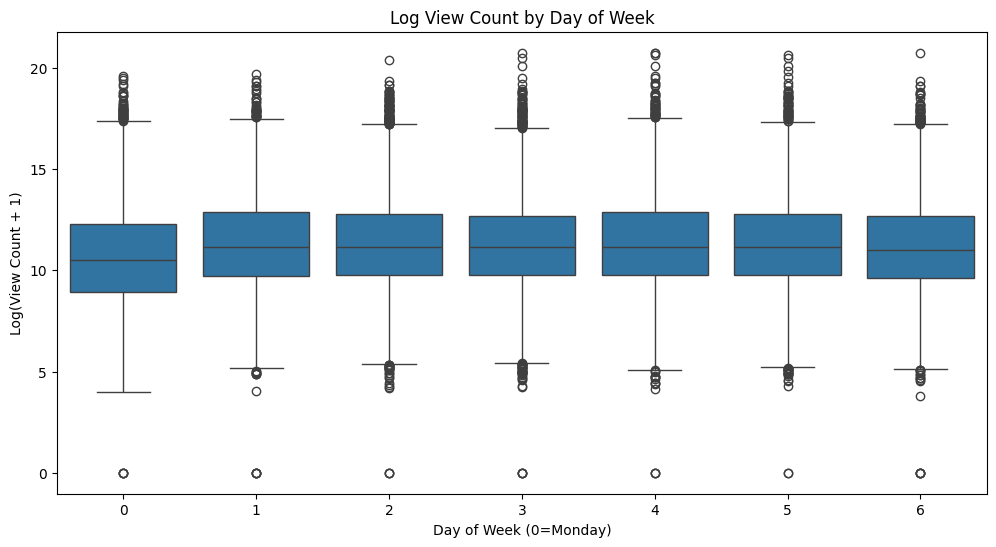

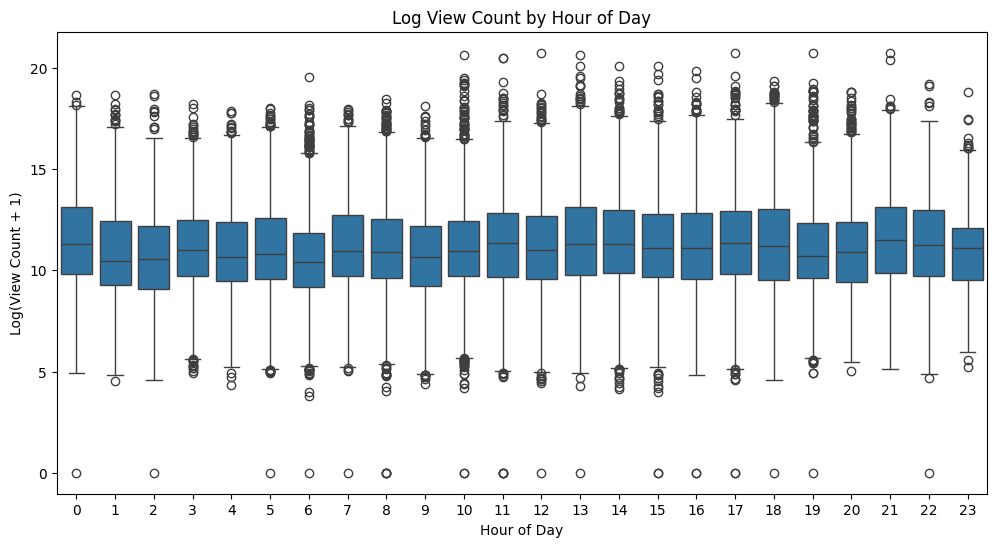

In [10]:
if 'publishedAt' in df_merged.columns:
    df_merged['published_at'] = pd.to_datetime(df_merged['publishedAt']) 
    df_merged['publish_hour'] = df_merged['published_at'].dt.hour
    df_merged['publish_day_of_week'] = df_merged['published_at'].dt.dayofweek
    df_merged['publish_month'] = df_merged['published_at'].dt.month

    plt.figure(figsize=(12, 6))
    sns.boxplot(x='publish_day_of_week', y='log_view_count', data=df_merged)
    plt.title('Log View Count by Day of Week')
    plt.xlabel('Day of Week (0=Monday)')
    plt.ylabel('Log(View Count + 1)')
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.boxplot(x='publish_hour', y='log_view_count', data=df_merged)
    plt.title('Log View Count by Hour of Day')
    plt.xlabel('Hour of Day')
    plt.ylabel('Log(View Count + 1)')
    plt.show()